# Simulasi Aliran Air pada Tanah Rawa (Porous Media Flow)

Created by:

**Al Zakaria, S.Pd.**

Supervised by:

**Amar Vijai Nasrulloh, S.Si., M.T., Ph.D.**

____________________________________________________________________

Notebook ini memodelkan **aliran air pada tanah rawa** dengan dua pendekatan:

1. **Finite Difference Method (FDM)** untuk solusi numerik referensi  
2. **Physics-Informed Neural Network (PINN)** dengan **PyTorch** dan **GPU** bila tersedia

Persamaan yang digunakan:

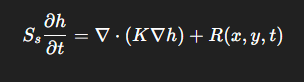

dengan:
- \(h(x,y,t)\): hydraulic head / tinggi muka air
- \(S_s\): specific storage
- \(K\): hydraulic conductivity
- \(R\): source term, misalnya infiltrasi hujan


## 1. Import library dan konfigurasi GPU

Bagian ini otomatis memakai **CUDA/GPU** untuk proses PyTorch jika tersedia.
Jika GPU tidak tersedia, notebook tetap berjalan dengan CPU.


In [15]:

import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import psutil
import imageio.v2 as imageio
from pathlib import Path
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import traceback


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Lebih cepat di GPU modern (Ampere, termasuk RTX 3050)
torch.set_float32_matmul_precision("high")

# Konfigurasi device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device yang digunakan:", device)

if torch.cuda.is_available():
    print("Nama GPU:", torch.cuda.get_device_name(0))
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
else:
    print("CUDA tidak tersedia, training akan berjalan di CPU.")

# ================================
# Informasi RAM (System Memory)
# ================================
ram = psutil.virtual_memory()

print("\n===== SYSTEM RAM =====")
print(f"Total RAM     : {ram.total / (1024**3):.2f} GB")
print(f"Available RAM : {ram.available / (1024**3):.2f} GB")
print(f"Used RAM      : {ram.used / (1024**3):.2f} GB")
print(f"RAM Usage     : {ram.percent} %")

# ================================
# Informasi VRAM GPU
# ================================
if torch.cuda.is_available():
    gpu_id = torch.cuda.current_device()

    total_vram = torch.cuda.get_device_properties(gpu_id).total_memory
    allocated_vram = torch.cuda.memory_allocated(gpu_id)
    reserved_vram = torch.cuda.memory_reserved(gpu_id)

    print("\n===== GPU VRAM =====")
    print(f"GPU Name        : {torch.cuda.get_device_name(gpu_id)}")
    print(f"Total VRAM      : {total_vram / (1024**3):.2f} GB")
    print(f"Allocated VRAM  : {allocated_vram / (1024**3):.2f} GB")
    print(f"Reserved VRAM   : {reserved_vram / (1024**3):.2f} GB")
    print(f"Free VRAM       : {(total_vram - reserved_vram) / (1024**3):.2f} GB")
else:
    print("\nGPU tidak tersedia.")

Device yang digunakan: cuda
Nama GPU: NVIDIA GeForce RTX 3050

===== SYSTEM RAM =====
Total RAM     : 31.84 GB
Available RAM : 14.11 GB
Used RAM      : 17.73 GB
RAM Usage     : 55.7 %

===== GPU VRAM =====
GPU Name        : NVIDIA GeForce RTX 3050
Total VRAM      : 8.00 GB
Allocated VRAM  : 0.02 GB
Reserved VRAM   : 0.12 GB
Free VRAM       : 7.88 GB


## 2. Parameter fisika dan domain simulasi

**a. Panjang domain (m)**

`Lx` dan `Ly` menyatakan ukuran area simulasi dua dimensi. Pada notebook ini domain tetap `50 m × 50 m`.

**b. Waktu (jam)**

Simulasi sekarang memakai satuan **jam**, bukan hari, agar lebih realistis untuk kejadian hujan.
- `T_end = 6.0` berarti total simulasi 6 jam
- hujan aktif terutama pada 0 sampai sekitar 3 jam, lalu sistem dibiarkan merespons sampai akhir simulasi

**c. Grid spasial**
- `Nx` = jumlah titik arah `x`
- `Ny` = jumlah titik arah `y`

Dengan `Nx = Ny = 51`, jarak grid menjadi `1 m`.

**d. Langkah waktu FDM**

`dt` dibatasi oleh syarat stabilitas skema eksplisit dan juga oleh `TARGET_DT_HOURS` agar resolusi waktu cukup halus untuk kejadian hujan per jam.

**e. Hydraulic conductivity**

Di kode, `K_day` tetap disediakan dalam `m/hari`, lalu otomatis dikonversi menjadi `K` dalam `m/jam` supaya konsisten dengan skala waktu baru.

**f. Specific storage**

`Ss` menyatakan kapasitas simpan air media berpori dalam model sederhana ini.


In [16]:
# ============================================================
# PARAMETER FISIK DAN DOMAIN
# ============================================================
Lx, Ly = 50.0, 50.0                  # panjang domain (m)
TIME_UNIT_LABEL = "jam"
T_end = 6.0                          # total simulasi (jam), realistis untuk kejadian hujan

Nx, Ny = 51, 51                      # grid spasial
TARGET_DT_HOURS = 0.10               # target resolusi waktu agar snapshot per jam cukup halus
INITIAL_HEAD = 1.0                   # hydraulic head awal (m)
BOUNDARY_HEAD = 1.0                  # Dirichlet boundary head (m)

# Parameter hidrologi
K_day = 0.8                          # hydraulic conductivity asli (m/day)
K = K_day / 24.0                     # konversi ke m/jam
Ss = 0.15                            # specific storage
D = K / Ss                           # diffusivity sederhana (m^2/jam)

# Syarat stabilitas skema explicit 2D: rx + ry <= 0.5
# dengan rx = D*dt/dx^2 dan ry = D*dt/dy^2
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)
dt_stable = 0.5 / (D * (1.0 / dx**2 + 1.0 / dy**2))
stability_safety = 0.90

dt = min(dt_stable * stability_safety, TARGET_DT_HOURS)
Nt = int(np.ceil(T_end / dt))
dt = T_end / Nt

t_arr = np.linspace(0, T_end, Nt + 1)
X, Y = np.meshgrid(x, y, indexing='ij')

def nearest_time_index(t_value):
    return int(np.argmin(np.abs(t_arr - float(t_value))))

print(f"dx={dx:.3f} m, dy={dy:.3f} m, dt={dt:.3f} {TIME_UNIT_LABEL}, Nt={Nt}")
print(f"dt_stable(max)={dt_stable:.3f} {TIME_UNIT_LABEL}, dt_target={TARGET_DT_HOURS:.3f} {TIME_UNIT_LABEL}, safety={stability_safety:.2f}")
print(f"K={K:.5f} m/jam (setara {K_day:.3f} m/hari), D={D:.5f} m^2/jam")


dx=1.000 m, dy=1.000 m, dt=0.100 jam, Nt=60
dt_stable(max)=1.125 jam, dt_target=0.100 jam, safety=0.90
K=0.03333 m/jam (setara 0.800 m/hari), D=0.22222 m^2/jam


## 3. Source term infiltrasi hujan multi-titik, kondisi awal, dan kondisi batas


In [17]:
# ============================================================
# SOURCE TERM / INFILTRASI HUJAN MULTI-TITIK
# ============================================================
RAIN_FIELD_CONFIG = {
    "seed": SEED + 7,
    "num_cells": 18,
    "x_margin_m": 4.0,
    "y_margin_m": 4.0,
    "sigma_range_m": (1.5, 3.8),
    "intensity_range_m_per_hour": (0.0015, 0.0040),
}

# Jika ingin mengubah pola hujan secara manual, edit variabel berikut lalu jalankan refresh_rain_tensors().
_rain_rng = np.random.default_rng(RAIN_FIELD_CONFIG["seed"])
RAIN_CELL_CENTERS = np.column_stack([
    _rain_rng.uniform(RAIN_FIELD_CONFIG["x_margin_m"], Lx - RAIN_FIELD_CONFIG["x_margin_m"], size=RAIN_FIELD_CONFIG["num_cells"]),
    _rain_rng.uniform(RAIN_FIELD_CONFIG["y_margin_m"], Ly - RAIN_FIELD_CONFIG["y_margin_m"], size=RAIN_FIELD_CONFIG["num_cells"]),
]).astype(np.float64)
RAIN_CELL_SIGMAS = _rain_rng.uniform(*RAIN_FIELD_CONFIG["sigma_range_m"], size=RAIN_FIELD_CONFIG["num_cells"]).astype(np.float64)
RAIN_CELL_INTENSITIES = _rain_rng.uniform(*RAIN_FIELD_CONFIG["intensity_range_m_per_hour"], size=RAIN_FIELD_CONFIG["num_cells"]).astype(np.float64)

RAIN_TIME_BREAKPOINTS_HOURS = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, T_end], dtype=np.float64)
RAIN_TIME_MULTIPLIERS = np.array([0.25, 0.60, 0.95, 1.00, 0.82, 0.55, 0.18, 0.00, 0.00], dtype=np.float64)

def refresh_rain_tensors():
    global RAIN_CENTERS_X_T, RAIN_CENTERS_Y_T, RAIN_SIGMAS_T, RAIN_INTENSITIES_T
    global RAIN_TIME_BREAKPOINTS_T, RAIN_TIME_MULTIPLIERS_T, RAIN_MARKER_SIZES

    RAIN_CENTERS_X_T = torch.tensor(RAIN_CELL_CENTERS[:, 0], dtype=torch.float32, device=device).view(1, -1)
    RAIN_CENTERS_Y_T = torch.tensor(RAIN_CELL_CENTERS[:, 1], dtype=torch.float32, device=device).view(1, -1)
    RAIN_SIGMAS_T = torch.tensor(RAIN_CELL_SIGMAS, dtype=torch.float32, device=device).view(1, -1)
    RAIN_INTENSITIES_T = torch.tensor(RAIN_CELL_INTENSITIES, dtype=torch.float32, device=device).view(1, -1)
    RAIN_TIME_BREAKPOINTS_T = torch.tensor(RAIN_TIME_BREAKPOINTS_HOURS, dtype=torch.float32, device=device)
    RAIN_TIME_MULTIPLIERS_T = torch.tensor(RAIN_TIME_MULTIPLIERS, dtype=torch.float32, device=device)

    peak_intensity = max(float(np.max(RAIN_CELL_INTENSITIES)), 1e-12)
    RAIN_MARKER_SIZES = 40.0 + 180.0 * (RAIN_CELL_INTENSITIES / peak_intensity)

refresh_rain_tensors()

print(f"Pola hujan multi-titik: {len(RAIN_CELL_CENTERS)} titik acak")
print("Ubah RAIN_CELL_CENTERS, RAIN_CELL_SIGMAS, RAIN_CELL_INTENSITIES, atau RAIN_TIME_MULTIPLIERS lalu jalankan refresh_rain_tensors() untuk memodifikasi hujan.")

def rainfall_temporal_profile_np(t):
    t_arr_local = np.asarray(t, dtype=np.float64)
    return np.interp(
        t_arr_local,
        RAIN_TIME_BREAKPOINTS_HOURS,
        RAIN_TIME_MULTIPLIERS,
        left=0.0,
        right=0.0,
    )

def rainfall_temporal_profile_torch(t):
    profile = torch.zeros_like(t)
    n_segments = len(RAIN_TIME_BREAKPOINTS_HOURS) - 1

    for i in range(n_segments):
        t0 = RAIN_TIME_BREAKPOINTS_T[i]
        t1 = RAIN_TIME_BREAKPOINTS_T[i + 1]
        v0 = RAIN_TIME_MULTIPLIERS_T[i]
        v1 = RAIN_TIME_MULTIPLIERS_T[i + 1]

        if i == n_segments - 1:
            mask = (t >= t0) & (t <= t1)
        else:
            mask = (t >= t0) & (t < t1)

        interp = v0 + (v1 - v0) * (t - t0) / torch.clamp(t1 - t0, min=1e-12)
        profile = torch.where(mask, interp, profile)

    return profile

def rainfall_source_np(X, Y, t):
    spatial = np.exp(
        -(
            (X[..., None] - RAIN_CELL_CENTERS[:, 0])**2
            + (Y[..., None] - RAIN_CELL_CENTERS[:, 1])**2
        ) / (2.0 * RAIN_CELL_SIGMAS**2)
    )
    base_rain = np.sum(spatial * RAIN_CELL_INTENSITIES.reshape(1, 1, -1), axis=2)
    temporal = rainfall_temporal_profile_np(t)
    return base_rain * temporal

def rainfall_source_torch(x, y, t):
    spatial = torch.exp(
        -(
            (x - RAIN_CENTERS_X_T)**2
            + (y - RAIN_CENTERS_Y_T)**2
        ) / (2.0 * RAIN_SIGMAS_T**2)
    )
    base_rain = torch.sum(spatial * RAIN_INTENSITIES_T, dim=1, keepdim=True)
    temporal = rainfall_temporal_profile_torch(t)
    return base_rain * temporal

# ============================================================
# KONDISI AWAL DAN BATAS
# ============================================================
def initial_condition_np(X, Y):
    return np.ones_like(X) * INITIAL_HEAD

def initial_condition_torch(x, y):
    return torch.ones_like(x) * INITIAL_HEAD

def boundary_value_torch(x, y, t):
    return torch.ones_like(x) * BOUNDARY_HEAD


Pola hujan multi-titik: 18 titik acak
Ubah RAIN_CELL_CENTERS, RAIN_CELL_SIGMAS, RAIN_CELL_INTENSITIES, atau RAIN_TIME_MULTIPLIERS lalu jalankan refresh_rain_tensors() untuk memodifikasi hujan.


## 4. Solver Finite Difference Method (FDM)

In [18]:
# ============================================================
# SOLVER FDM
# ============================================================
def solve_fdm():
    '''
    Menyelesaikan:
    dh/dt = D (d2h/dx2 + d2h/dy2) + R/Ss
    '''
    h = np.zeros((Nt + 1, Nx, Ny), dtype=np.float64)
    h[0] = initial_condition_np(X, Y)

    # Boundary awal
    h[0, 0, :] = BOUNDARY_HEAD
    h[0, -1, :] = BOUNDARY_HEAD
    h[0, :, 0] = BOUNDARY_HEAD
    h[0, :, -1] = BOUNDARY_HEAD

    rx = D * dt / dx**2
    ry = D * dt / dy**2
    print(f"Stability indicators -> rx={rx:.4f}, ry={ry:.4f}, rx+ry={rx+ry:.4f}")

    if rx + ry > 0.5:
        print("WARNING: Skema explicit berpotensi tidak stabil. Kurangi dt atau ubah grid.")

    for n in range(Nt):
        hn = h[n].copy()
        hnew = hn.copy()
        source = rainfall_source_np(X, Y, t_arr[n]) / Ss

        hnew[1:-1, 1:-1] = (
            hn[1:-1, 1:-1]
            + rx * (hn[2:, 1:-1] - 2 * hn[1:-1, 1:-1] + hn[:-2, 1:-1])
            + ry * (hn[1:-1, 2:] - 2 * hn[1:-1, 1:-1] + hn[1:-1, :-2])
            + dt * source[1:-1, 1:-1]
        )

        # Dirichlet boundary
        hnew[0, :] = BOUNDARY_HEAD
        hnew[-1, :] = BOUNDARY_HEAD
        hnew[:, 0] = BOUNDARY_HEAD
        hnew[:, -1] = BOUNDARY_HEAD

        h[n + 1] = hnew

    return h


## 5. Arsitektur PINN berbasis PyTorch dengan GPU

In [19]:
# ============================================================
# MODEL PINN
# ============================================================
class PINN(nn.Module):
    def __init__(self, in_dim=3, hidden_dim=96, num_hidden=5, out_dim=1):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, xyt):
        # Normalisasi input agar training lebih stabil
        x = xyt[:, 0:1] / Lx
        y = xyt[:, 1:2] / Ly
        t = xyt[:, 2:3] / T_end
        inp = torch.cat([x, y, t], dim=1)
        return self.net(inp)


def pinn_residual(model, x, y, t):
    # Residual PDE: Ss*h_t - K*(h_xx + h_yy) - R = 0
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)

    inp = torch.cat([x, y, t], dim=1)
    h = model(inp)

    h_x = torch.autograd.grad(h, x, grad_outputs=torch.ones_like(h), create_graph=True, retain_graph=True)[0]
    h_y = torch.autograd.grad(h, y, grad_outputs=torch.ones_like(h), create_graph=True, retain_graph=True)[0]
    h_t = torch.autograd.grad(h, t, grad_outputs=torch.ones_like(h), create_graph=True, retain_graph=True)[0]

    h_xx = torch.autograd.grad(h_x, x, grad_outputs=torch.ones_like(h_x), create_graph=True, retain_graph=True)[0]
    h_yy = torch.autograd.grad(h_y, y, grad_outputs=torch.ones_like(h_y), create_graph=True, retain_graph=True)[0]

    R = rainfall_source_torch(x, y, t)
    residual = Ss * h_t - K * (h_xx + h_yy) - R
    return residual


## 6. Sampling titik training PINN dan data dummy observasi


In [20]:
# ============================================================
# SAMPLING DATA TRAINING PINN
# ============================================================
def sample_interior(n):
    x = torch.rand((n, 1), device=device) * Lx
    y = torch.rand((n, 1), device=device) * Ly
    t = torch.rand((n, 1), device=device) * T_end
    return x, y, t

def sample_initial(n):
    x = torch.rand((n, 1), device=device) * Lx
    y = torch.rand((n, 1), device=device) * Ly
    t = torch.zeros((n, 1), device=device)
    h0 = initial_condition_torch(x, y)
    return x, y, t, h0

def sample_boundary(n):
    n_side = n // 4

    # x = 0
    x1 = torch.zeros((n_side, 1), device=device)
    y1 = torch.rand((n_side, 1), device=device) * Ly
    t1 = torch.rand((n_side, 1), device=device) * T_end

    # x = Lx
    x2 = torch.ones((n_side, 1), device=device) * Lx
    y2 = torch.rand((n_side, 1), device=device) * Ly
    t2 = torch.rand((n_side, 1), device=device) * T_end

    # y = 0
    x3 = torch.rand((n_side, 1), device=device) * Lx
    y3 = torch.zeros((n_side, 1), device=device)
    t3 = torch.rand((n_side, 1), device=device) * T_end

    # y = Ly
    x4 = torch.rand((n_side, 1), device=device) * Lx
    y4 = torch.ones((n_side, 1), device=device) * Ly
    t4 = torch.rand((n_side, 1), device=device) * T_end

    x = torch.cat([x1, x2, x3, x4], dim=0)
    y = torch.cat([y1, y2, y3, y4], dim=0)
    t = torch.cat([t1, t2, t3, t4], dim=0)
    hb = boundary_value_torch(x, y, t)
    return x, y, t, hb

DUMMY_PINN_DATA_CONFIG = {
    "times_hours": np.array([1.0, 2.0, 3.0], dtype=np.float64),
    "sensor_points_xy_m": np.array([
        [6.0, 8.0],
        [12.0, 14.0],
        [19.0, 9.0],
        [27.0, 15.0],
        [35.0, 10.0],
        [43.0, 18.0],
        [8.0, 27.0],
        [16.0, 34.0],
        [24.0, 26.0],
        [32.0, 37.0],
        [40.0, 29.0],
        [22.0, 43.0],
    ], dtype=np.float64),
    "hourly_bias_m": np.array([0.003, 0.007, 0.010], dtype=np.float64),
    "noise_std_m": 0.003,
    "seed": SEED + 17,
    "note": (
        "CATATAN: DUMMY_PINN_OBSERVATIONS adalah data dummy untuk training PINN "
        "pada jam ke-1, 2, dan 3. Ganti dengan data lapangan agar simulasi lebih akurat."
    ),
}

DUMMY_PINN_OBSERVATIONS = None

def sample_field_at_sensor_points(field, sensor_points_xy_m):
    sensor_points_xy_m = np.asarray(sensor_points_xy_m, dtype=np.float64)
    ix = np.clip(np.rint(sensor_points_xy_m[:, 0] / dx).astype(int), 0, Nx - 1)
    iy = np.clip(np.rint(sensor_points_xy_m[:, 1] / dy).astype(int), 0, Ny - 1)
    return field[ix, iy]

def build_dummy_pinn_observation_data(h_fdm):
    cfg = DUMMY_PINN_DATA_CONFIG
    times = np.asarray(cfg["times_hours"], dtype=np.float64)
    sensor_points = np.asarray(cfg["sensor_points_xy_m"], dtype=np.float64)
    hourly_bias = np.asarray(cfg["hourly_bias_m"], dtype=np.float64)

    if len(times) != len(hourly_bias):
        raise ValueError("times_hours dan hourly_bias_m harus punya panjang yang sama.")

    rng = np.random.default_rng(cfg["seed"])
    observed_rows = []
    reference_rows = []
    matched_times = []

    for hour, bias in zip(times, hourly_bias):
        idx = nearest_time_index(hour)
        ref_vals = sample_field_at_sensor_points(h_fdm[idx], sensor_points)
        noise = rng.normal(loc=0.0, scale=cfg["noise_std_m"], size=ref_vals.shape)
        obs_vals = np.clip(ref_vals + bias + noise, BOUNDARY_HEAD, None)

        reference_rows.append(ref_vals)
        observed_rows.append(obs_vals)
        matched_times.append(float(t_arr[idx]))

    return {
        "note": cfg["note"],
        "times_hours": times.copy(),
        "matched_time_hours": np.asarray(matched_times, dtype=np.float64),
        "sensor_points_xy_m": sensor_points.copy(),
        "hourly_bias_m": hourly_bias.copy(),
        "noise_std_m": float(cfg["noise_std_m"]),
        "fdm_reference_m": np.asarray(reference_rows, dtype=np.float64),
        "observed_head_m": np.asarray(observed_rows, dtype=np.float64),
    }

def describe_dummy_pinn_observations(obs_data):
    print(obs_data["note"])
    print("Waktu observasi dummy (jam):", obs_data["times_hours"])
    print("Waktu grid FDM yang dipakai (jam):", obs_data["matched_time_hours"])
    print("Koordinat sensor dummy (x, y) [m]:")
    print(np.array2string(obs_data["sensor_points_xy_m"], precision=2, suppress_small=True))
    print("Head dummy untuk training PINN [m] (baris = jam, kolom = sensor):")
    print(np.array2string(obs_data["observed_head_m"], precision=4, suppress_small=True))

def observation_data_to_torch(obs_data):
    times = np.asarray(obs_data["times_hours"], dtype=np.float32)
    sensor_points = np.asarray(obs_data["sensor_points_xy_m"], dtype=np.float32)
    observed_head = np.asarray(obs_data["observed_head_m"], dtype=np.float32)

    expected_shape = (len(times), len(sensor_points))
    if observed_head.shape != expected_shape:
        raise ValueError(
            f"observed_head_m harus berdimensi {expected_shape}, tetapi dapat {observed_head.shape}."
        )

    x_obs = np.tile(sensor_points[:, 0], len(times)).reshape(-1, 1)
    y_obs = np.tile(sensor_points[:, 1], len(times)).reshape(-1, 1)
    t_obs = np.repeat(times, len(sensor_points)).reshape(-1, 1)
    h_obs = observed_head.reshape(-1, 1)

    return (
        torch.tensor(x_obs, dtype=torch.float32, device=device),
        torch.tensor(y_obs, dtype=torch.float32, device=device),
        torch.tensor(t_obs, dtype=torch.float32, device=device),
        torch.tensor(h_obs, dtype=torch.float32, device=device),
    )


## 7. Training PINN di GPU dengan data observasi dummy


In [21]:
# ============================================================
# TRAINING PINN
# ============================================================
def train_pinn(
    epochs_adam=8000,
    epochs_lbfgs=300,
    n_int=2500,
    n_ini=1200,
    n_bnd=1200,
    lr=8e-4,
    w_pde=1.0,
    w_ini=25.0,
    w_bnd=25.0,
    obs_data=None,
    w_data=30.0,
):
    model = PINN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)
    obs_tensors = observation_data_to_torch(obs_data) if obs_data is not None else None

    history = []

    for epoch in range(1, epochs_adam + 1):
        optimizer.zero_grad(set_to_none=True)

        xi, yi, ti = sample_interior(n_int)
        res = pinn_residual(model, xi, yi, ti)
        loss_pde = torch.mean(res**2)

        x0, y0, t0, h0 = sample_initial(n_ini)
        pred0 = model(torch.cat([x0, y0, t0], dim=1))
        loss_ini = torch.mean((pred0 - h0)**2)

        xb, yb, tb, hb = sample_boundary(n_bnd)
        predb = model(torch.cat([xb, yb, tb], dim=1))
        loss_bnd = torch.mean((predb - hb)**2)

        if obs_tensors is not None:
            xo, yo, to, ho = obs_tensors
            predo = model(torch.cat([xo, yo, to], dim=1))
            loss_data = torch.mean((predo - ho)**2)
        else:
            loss_data = torch.zeros(1, device=device)

        loss = w_pde * loss_pde + w_ini * loss_ini + w_bnd * loss_bnd + w_data * loss_data
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        history.append(loss.item())

        if epoch % 500 == 0 or epoch == 1:
            print(
                f"[Adam] Epoch {epoch:5d} | "
                f"Total={loss.item():.6e} | "
                f"PDE={loss_pde.item():.6e} | "
                f"IC={loss_ini.item():.6e} | "
                f"BC={loss_bnd.item():.6e} | "
                f"DATA={loss_data.item():.6e} | "
                f"LR={optimizer.param_groups[0]['lr']:.2e}"
            )

    lbfgs = optim.LBFGS(
        model.parameters(),
        lr=0.6,
        max_iter=epochs_lbfgs,
        tolerance_grad=1e-9,
        tolerance_change=1e-11,
        history_size=50,
        line_search_fn='strong_wolfe'
    )

    xi, yi, ti = sample_interior(n_int)
    x0, y0, t0, h0 = sample_initial(n_ini)
    xb, yb, tb, hb = sample_boundary(n_bnd)

    if obs_tensors is not None:
        xo, yo, to, ho = obs_tensors

    def closure():
        lbfgs.zero_grad(set_to_none=True)

        res = pinn_residual(model, xi, yi, ti)
        loss_pde = torch.mean(res**2)

        pred0 = model(torch.cat([x0, y0, t0], dim=1))
        loss_ini = torch.mean((pred0 - h0)**2)

        predb = model(torch.cat([xb, yb, tb], dim=1))
        loss_bnd = torch.mean((predb - hb)**2)

        if obs_tensors is not None:
            predo = model(torch.cat([xo, yo, to], dim=1))
            loss_data = torch.mean((predo - ho)**2)
        else:
            loss_data = torch.zeros(1, device=device)

        loss = w_pde * loss_pde + w_ini * loss_ini + w_bnd * loss_bnd + w_data * loss_data
        loss.backward()
        return loss

    final_loss = lbfgs.step(closure)
    final_loss_value = float(final_loss.detach().cpu()) if torch.is_tensor(final_loss) else float(final_loss)
    history.append(final_loss_value)
    print(f"[LBFGS] Final loss={final_loss_value:.6e}")

    return model, history


## 8. Evaluasi model PINN

In [22]:

# ============================================================
# EVALUASI PINN PADA GRID
# ============================================================
def predict_pinn(model, t_eval):
    XX, YY = np.meshgrid(x, y, indexing='ij')

    x_t = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32, device=device)
    y_t = torch.tensor(YY.reshape(-1, 1), dtype=torch.float32, device=device)
    t_t = torch.full_like(x_t, float(t_eval), device=device)

    model.eval()
    with torch.no_grad():
        pred = model(torch.cat([x_t, y_t, t_t], dim=1)).detach().cpu().numpy()

    return pred.reshape(Nx, Ny)

## 9. Fungsi visualisasi

In [23]:
# ============================================================
# VISUALISASI
# ============================================================
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

FLOW_CMAP = 'viridis'

def _observation_points_xy():
    obs_data = globals().get("DUMMY_PINN_OBSERVATIONS")
    if isinstance(obs_data, dict) and "sensor_points_xy_m" in obs_data:
        points = np.asarray(obs_data["sensor_points_xy_m"], dtype=np.float64)
        if points.ndim == 2 and points.shape[1] == 2:
            return points
    return np.empty((0, 2), dtype=np.float64)

def _plot_rain_markers(ax):
    ax.scatter(
        RAIN_CELL_CENTERS[:, 0],
        RAIN_CELL_CENTERS[:, 1],
        s=RAIN_MARKER_SIZES,
        c='deepskyblue',
        alpha=0.35,
        edgecolors='white',
        linewidths=0.7,
        zorder=5,
    )

def _plot_observation_markers(ax):
    obs_points = _observation_points_xy()
    if obs_points.size:
        ax.scatter(
            obs_points[:, 0],
            obs_points[:, 1],
            c='white',
            marker='s',
            s=28,
            edgecolors='black',
            linewidths=0.6,
            zorder=6,
        )

def _legend_handles(mode='flow'):
    handles = []

    if mode == 'flow':
        handles.extend([
            Patch(facecolor='#440154', edgecolor='k', label='Head rendah (zona lebih kering / tekanan rendah)'),
            Patch(facecolor='#21918c', edgecolor='k', label='Head sedang'),
            Patch(facecolor='#fde725', edgecolor='k', label='Head tinggi (zona lebih basah / tekanan tinggi)'),
        ])

    handles.append(
        Line2D([0], [0], marker='o', color='white', markerfacecolor='deepskyblue',
               markeredgecolor='white', linestyle='None', markersize=8,
               label='Titik hujan acak (forcing)')
    )

    if _observation_points_xy().size:
        handles.append(
            Line2D([0], [0], marker='s', color='black', markerfacecolor='white',
                   linestyle='None', markersize=6, label='Titik observasi dummy PINN')
        )


    return handles

def plot_result(field, title, vmin=None, vmax=None, cmap=FLOW_CMAP, colorbar_label='Hydraulic head h (m)', legend_mode='flow'):
    plt.figure(figsize=(7.4, 5.6))
    ax = plt.gca()

    cf = ax.contourf(X, Y, field, levels=80, vmin=vmin, vmax=vmax, cmap=cmap)
    cbar = plt.colorbar(cf, ax=ax, label=colorbar_label)
    cbar.ax.set_title('Rendah -> Tinggi', fontsize=9, pad=8)

    _plot_rain_markers(ax)
    _plot_observation_markers(ax)

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title(title)

    handles = _legend_handles(mode=legend_mode)
    leg = ax.legend(handles=handles, loc='upper left', fontsize=8, framealpha=0.9, title='Legenda', title_fontsize=9)
    leg.get_frame().set_edgecolor('black')

    plt.tight_layout()
    plt.show()

def plot_history(history):
    plt.figure(figsize=(7, 4))
    plt.plot(history, label='Total loss PINN')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('PINN Training Loss')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


## 10. Jalankan simulasi FDM

Stability indicators -> rx=0.0222, ry=0.0222, rx+ry=0.0444
CATATAN: DUMMY_PINN_OBSERVATIONS adalah data dummy untuk training PINN pada jam ke-1, 2, dan 3. Ganti dengan data lapangan agar simulasi lebih akurat.
Waktu observasi dummy (jam): [1. 2. 3.]
Waktu grid FDM yang dipakai (jam): [1. 2. 3.]
Koordinat sensor dummy (x, y) [m]:
[[ 6.  8.]
 [12. 14.]
 [19.  9.]
 [27. 15.]
 [35. 10.]
 [43. 18.]
 [ 8. 27.]
 [16. 34.]
 [24. 26.]
 [32. 37.]
 [40. 29.]
 [22. 43.]]
Head dummy untuk training PINN [m] (baris = jam, kolom = sensor):
[[1.0088 1.0078 1.0132 1.0109 1.0052 1.0015 1.0127 1.0034 1.0096 1.0047
  1.009  1.0097]
 [1.0334 1.0072 1.0167 1.0324 1.0192 1.0052 1.0368 1.0141 1.004  1.0145
  1.0167 1.0192]
 [1.0386 1.0059 1.0292 1.0403 1.0322 1.0149 1.0444 1.0277 1.0117 1.0157
  1.0164 1.0307]]


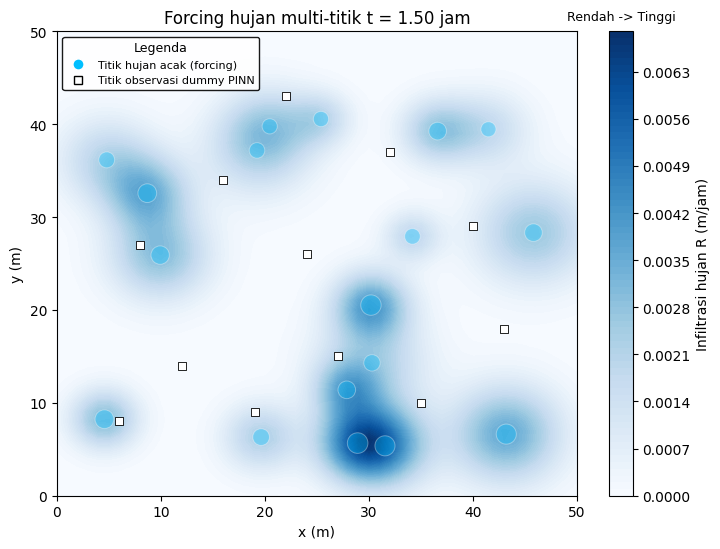

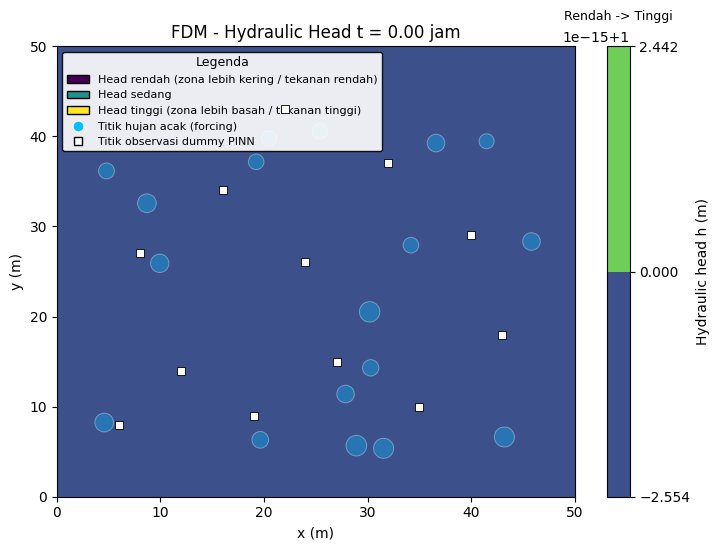

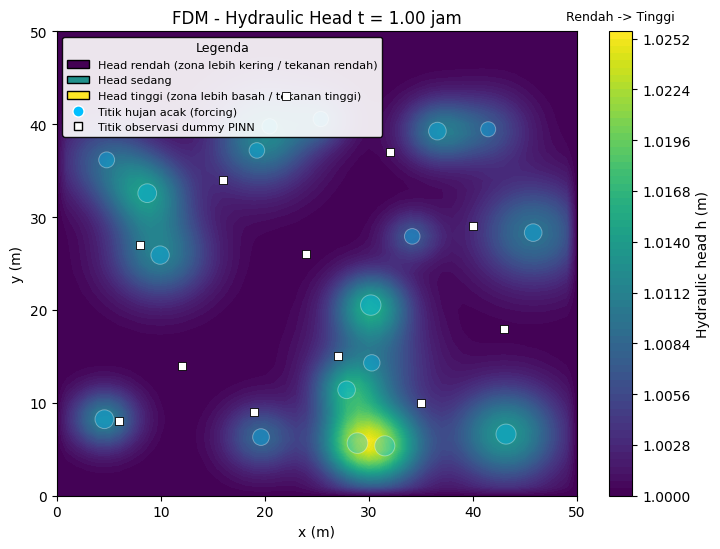

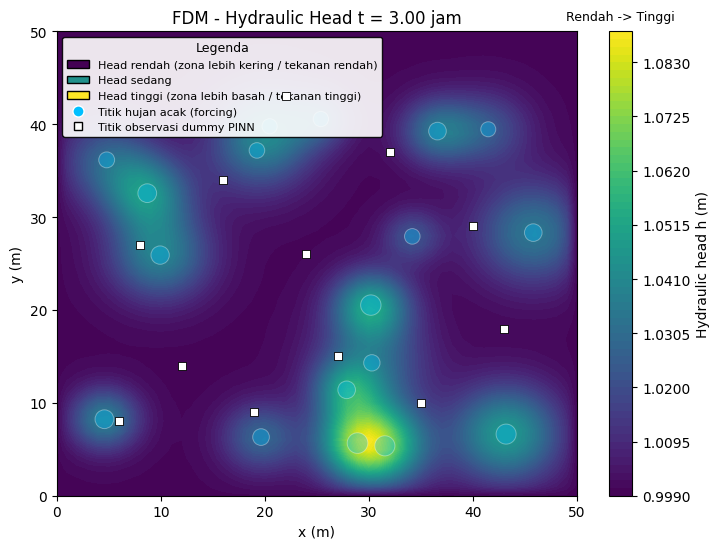

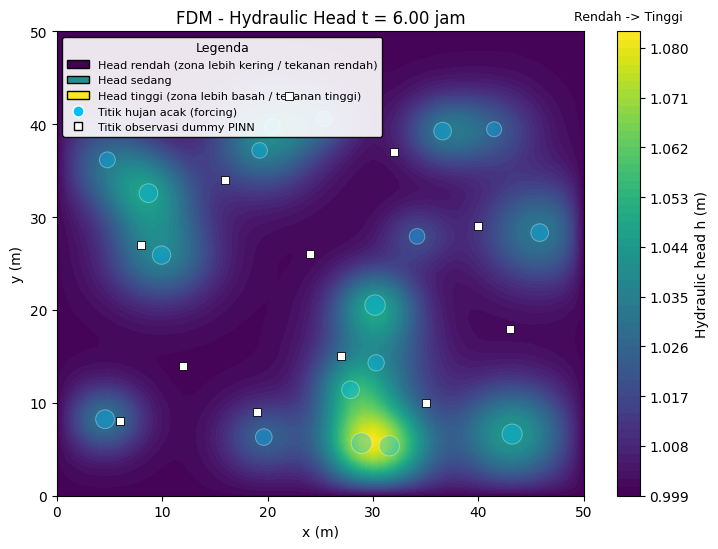

In [24]:
# Jalankan FDM
h_fdm = solve_fdm()

# Bangun data dummy observasi untuk training PINN
DUMMY_PINN_OBSERVATIONS = build_dummy_pinn_observation_data(h_fdm)
describe_dummy_pinn_observations(DUMMY_PINN_OBSERVATIONS)

# Plot forcing hujan multi-titik
plot_result(
    rainfall_source_np(X, Y, 1.5),
    "Forcing hujan multi-titik t = 1.50 jam",
    cmap='Blues',
    colorbar_label='Infiltrasi hujan R (m/jam)',
    legend_mode='rain',
)

# Snapshot FDM
snapshot_hours = [0.0, 1.0, 3.0, T_end]
for t_plot in snapshot_hours:
    idx_plot = nearest_time_index(t_plot)
    plot_result(h_fdm[idx_plot], f"FDM - Hydraulic Head t = {t_arr[idx_plot]:.2f} jam")


## 11. Training PINN

Catatan:
- `DUMMY_PINN_OBSERVATIONS` adalah **data dummy** pada jam ke-1, ke-2, dan ke-3.
- Data ini hanya placeholder agar alur training PINN bisa diuji.
- Ubah `DUMMY_PINN_DATA_CONFIG` untuk regenerasi data dummy, atau edit `DUMMY_PINN_OBSERVATIONS["observed_head_m"]` bila ingin mengubah nilainya manual.
- Ganti data dummy tersebut dengan data lapangan aktual agar PINN lebih akurat mensimulasikan kondisi nyata.
- Jika GPU aktif, proses training PyTorch otomatis berjalan di GPU.
- Bila ingin mempercepat uji awal, kurangi `epochs`.


[Adam] Epoch     1 | Total=6.147511e+01 | PDE=1.205814e-06 | IC=7.458345e-01 | BC=7.648314e-01 | DATA=7.902820e-01 | LR=8.00e-04
[Adam] Epoch   500 | Total=1.182575e-02 | PDE=7.036652e-07 | IC=9.638492e-05 | BC=5.619928e-05 | DATA=2.670148e-04 | LR=8.00e-04
[Adam] Epoch  1000 | Total=6.936317e-03 | PDE=7.671543e-07 | IC=4.542298e-05 | BC=2.675340e-05 | DATA=1.710380e-04 | LR=8.00e-04
[Adam] Epoch  1500 | Total=6.857982e-03 | PDE=8.509983e-07 | IC=3.195109e-05 | BC=1.085438e-04 | DATA=1.114920e-04 | LR=8.00e-04
[Adam] Epoch  2000 | Total=5.773845e-03 | PDE=8.842027e-07 | IC=2.216351e-05 | BC=7.774917e-05 | DATA=1.091715e-04 | LR=4.00e-04
[Adam] Epoch  2500 | Total=4.402825e-03 | PDE=6.891756e-07 | IC=4.169317e-06 | BC=5.151232e-05 | DATA=1.003365e-04 | LR=4.00e-04
[Adam] Epoch  3000 | Total=4.084763e-03 | PDE=6.106506e-07 | IC=1.923271e-06 | BC=3.833335e-05 | DATA=1.025912e-04 | LR=4.00e-04
[Adam] Epoch  3500 | Total=4.026596e-03 | PDE=6.099085e-07 | IC=1.476904e-06 | BC=3.558167e-05 | 

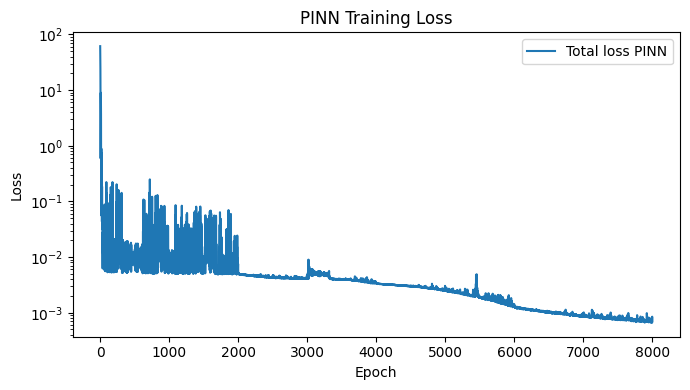

In [25]:
model, history = train_pinn(
    epochs_adam=8000,
    epochs_lbfgs=300,
    n_int=2500,
    n_ini=1200,
    n_bnd=1200,
    lr=8e-4,
    obs_data=DUMMY_PINN_OBSERVATIONS,
    w_data=30.0,
)

plot_history(history)


## 12. Perbandingan hasil PINN vs FDM

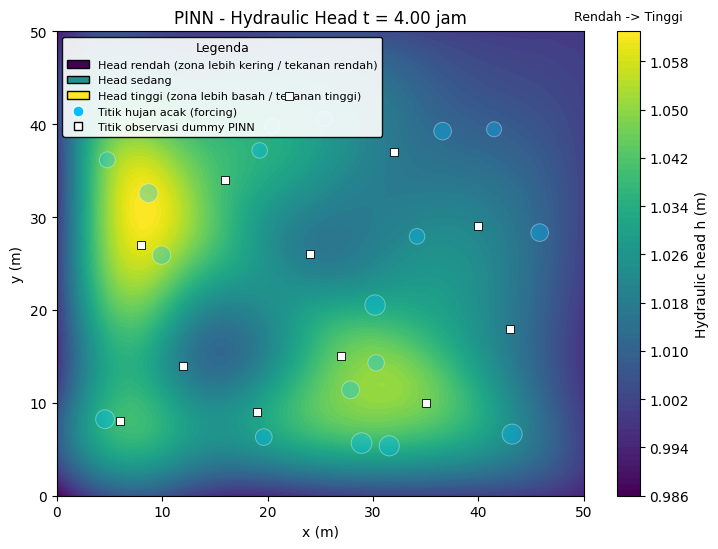

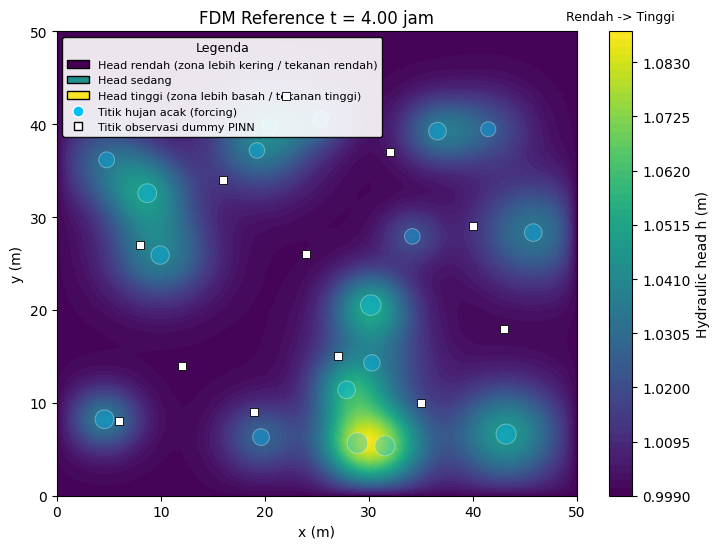

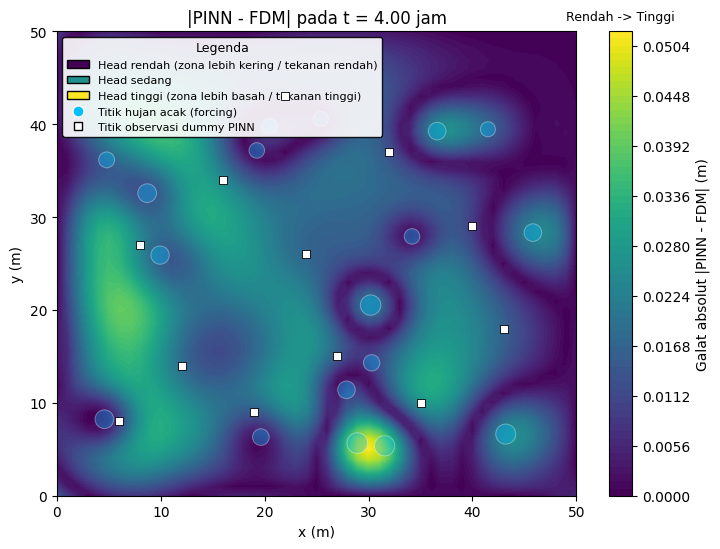

RMSE PINN vs FDM pada t=4.00 jam: 0.017323


In [26]:
# Evaluasi PINN pada waktu tertentu
t_test = 4.0
h_pinn = predict_pinn(model, t_test)

# FDM reference di waktu terdekat
idx_t = np.argmin(np.abs(t_arr - t_test))
h_ref = h_fdm[idx_t]

# Plot hasil
plot_result(h_pinn, f"PINN - Hydraulic Head t = {t_test:.2f} jam")
plot_result(h_ref, f"FDM Reference t = {t_arr[idx_t]:.2f} jam")

# Error absolut
abs_err = np.abs(h_pinn - h_ref)
plot_result(
    abs_err,
    f"|PINN - FDM| pada t = {t_arr[idx_t]:.2f} jam",
    colorbar_label='Galat absolut |PINN - FDM| (m)',
)

# RMSE
rmse = np.sqrt(np.mean((h_pinn - h_ref)**2))
print(f"RMSE PINN vs FDM pada t={t_arr[idx_t]:.2f} jam: {rmse:.6f}")


## 13. Animation FDM vs PINN

In [27]:
from pathlib import Path
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import traceback
import time

base = Path.cwd()
fdm_dir = base / "frames_fdm"
pinn_dir = base / "frames_pinn"
fdm_dir.mkdir(exist_ok=True)
pinn_dir.mkdir(exist_ok=True)

print(f"[INFO] Working dir      : {base}", flush=True)
print(f"[INFO] frames_fdm dir   : {fdm_dir}", flush=True)
print(f"[INFO] frames_pinn dir  : {pinn_dir}", flush=True)

# Uji cepat apakah file PNG bisa ditulis
try:
    test_png = fdm_dir / "_write_test.png"
    fig, ax = plt.subplots(figsize=(3, 2))
    ax.plot([0, 1], [0, 1])
    ax.set_title('write-test')
    fig.savefig(str(test_png), dpi=80)
    plt.close(fig)
    print(f"[INFO] Write test PNG ok: {test_png.exists()} -> {test_png}", flush=True)
except Exception:
    print('[ERROR] Gagal write test PNG', flush=True)
    traceback.print_exc()

def _save_frame(field, title, filename, vmin=None, vmax=None, cmap='viridis'):
    fig, ax = plt.subplots(figsize=(7.2, 5.6))
    cf = ax.contourf(X, Y, field, levels=80, vmin=vmin, vmax=vmax, cmap=cmap)
    cbar = plt.colorbar(cf, ax=ax, label='Hydraulic head h (m)')
    cbar.ax.set_title('Rendah -> Tinggi', fontsize=9, pad=8)

    _plot_rain_markers(ax)
    _plot_observation_markers(ax)

    legend_handles = _legend_handles(mode='flow')
    ax.legend(handles=legend_handles, loc='upper left', fontsize=8, framealpha=0.9, title='Legenda', title_fontsize=9)

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(str(filename), dpi=130)
    plt.close(fig)

def _frame_indices(n_total, stride=6, max_frames=180):
    idx = list(range(0, n_total, stride))
    if len(idx) > max_frames:
        step = max(1, len(idx) // max_frames)
        idx = idx[::step]
    return idx

def make_fdm_gif(h_fdm, t_arr, out_gif='fdm_animation.gif', stride=6, fps=10, vmin=None, vmax=None, max_frames=180):
    files = []
    vmin = float(np.min(h_fdm)) if vmin is None else float(vmin)
    vmax = float(np.max(h_fdm)) if vmax is None else float(vmax)
    idx_list = _frame_indices(len(t_arr), stride=stride, max_frames=max_frames)

    print(f"[FDM] Start | total_t={len(t_arr)} | frames={len(idx_list)}", flush=True)
    t0 = time.time()
    for k, idx in enumerate(idx_list, 1):
        fname = fdm_dir / f'frame_{idx:04d}.png'
        _save_frame(h_fdm[idx], f'FDM: t = {t_arr[idx]:.2f} jam', fname, vmin=vmin, vmax=vmax, cmap='viridis')
        files.append(str(fname))
        if (k % 20 == 0) or (k == len(idx_list)):
            print(f"[FDM] frame {k}/{len(idx_list)}", flush=True)

    if not files:
        raise RuntimeError('Tidak ada frame FDM yang dibuat.')

    images = [imageio.imread(f) for f in files]
    out_path = base / out_gif
    imageio.mimsave(str(out_path), images, fps=fps, loop=0)
    print(f"[FDM] Done in {time.time()-t0:.1f}s | GIF: {out_path} | frames={len(files)}", flush=True)
    return str(out_path)

def make_pinn_gif(model, t_arr, out_gif='pinn_animation.gif', stride=6, fps=10, vmin=None, vmax=None, max_frames=180):
    files = []
    idx_list = _frame_indices(len(t_arr), stride=stride, max_frames=max_frames)
    use_times = [float(t_arr[idx]) for idx in idx_list]

    print(f"[PINN] Start predict | frames={len(use_times)}", flush=True)
    t0 = time.time()
    fields = [predict_pinn(model, tt) for tt in use_times]
    stack = np.stack(fields, axis=0)

    vmin = float(np.min(stack)) if vmin is None else float(vmin)
    vmax = float(np.max(stack)) if vmax is None else float(vmax)

    for k, (idx, field) in enumerate(zip(idx_list, fields), 1):
        fname = pinn_dir / f'frame_{idx:04d}.png'
        _save_frame(field, f'PINN: t = {t_arr[idx]:.2f} jam', fname, vmin=vmin, vmax=vmax, cmap='viridis')
        files.append(str(fname))
        if (k % 20 == 0) or (k == len(idx_list)):
            print(f"[PINN] frame {k}/{len(idx_list)}", flush=True)

    if not files:
        raise RuntimeError('Tidak ada frame PINN yang dibuat.')

    images = [imageio.imread(f) for f in files]
    out_path = base / out_gif
    imageio.mimsave(str(out_path), images, fps=fps, loop=0)
    print(f"[PINN] Done in {time.time()-t0:.1f}s | GIF: {out_path} | frames={len(files)}", flush=True)
    return str(out_path)

try:
    sample_idx = _frame_indices(len(t_arr), stride=6, max_frames=120)
    sample_fields = [predict_pinn(model, float(t_arr[i])) for i in sample_idx]
    sample_stack = np.stack(sample_fields, axis=0)
    global_vmin = float(min(np.min(h_fdm), np.min(sample_stack)))
    global_vmax = float(max(np.max(h_fdm), np.max(sample_stack)))

    fdm_gif = make_fdm_gif(h_fdm, t_arr, out_gif='fdm_animation.gif', stride=6, fps=10, vmin=global_vmin, vmax=global_vmax, max_frames=180)
    pinn_gif = make_pinn_gif(model, t_arr, out_gif='pinn_animation.gif', stride=6, fps=10, vmin=global_vmin, vmax=global_vmax, max_frames=180)

    print(f"[INFO] Jumlah frame FDM : {len(list(fdm_dir.glob('*.png')))}", flush=True)
    print(f"[INFO] Jumlah frame PINN: {len(list(pinn_dir.glob('*.png')))}", flush=True)
except Exception:
    print('[ERROR] Proses GIF gagal', flush=True)
    traceback.print_exc()


[INFO] Working dir      : c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow-staging
[INFO] frames_fdm dir   : c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow-staging\frames_fdm
[INFO] frames_pinn dir  : c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow-staging\frames_pinn
[INFO] Write test PNG ok: True -> c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow-staging\frames_fdm\_write_test.png
[FDM] Start | total_t=61 | frames=11
[FDM] frame 11/11
[FDM] Done in 2.9s | GIF: c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow-staging\fdm_animation.gif | frames=11
[PINN] Start predict | frames=11
[PINN] frame 11/11
[PINN] Done in 2.8s | GIF: c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow-staging\pinn_animation.gif | frames=11
[INFO] Jumlah frame FDM : 12
[INFO] Jumlah frame PINN: 11


## 14. Evaluasi Komputasi

In [28]:
error = np.abs(h_pinn - h_ref)
print(np.mean(error))


0.014188964564860984


## 15. Pengembangan lanjutan

Model ini bisa dikembangkan menjadi:
- **permeabilitas heterogen**: \(K = K(x,y)\)
- **anisotropi**: \(K_x \neq K_y\)
- **boundary sungai atau kanal**
- **evapotranspirasi**
- **data curah hujan riil**
- **ganti data dummy observasi dengan data lapangan piezometer/sumur pantau per jam**
- **inverse PINN** untuk mengestimasi parameter dari data observasi lapangan
